In [3]:
# Importação e Preparação da Imagem
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Pega o local onde o notebook está rodando agora
diretorio_atual = os.getcwd() 

# Define o nome da imagem
nome_arquivo = 'image-cinza-lago.jpg'
caminho = os.path.join(diretorio_atual, nome_arquivo)

img_original = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print("Erro: Imagem não encontrada!")
else:
    # I. Preparação e Degradação
    # Aplicando a redução artificial de contraste
    img_degradada = (img_original * 0.2) + 120
    img_degradada = img_degradada.astype(np.uint8) # Converte de volta para 8 bits

In [4]:
# II. Limiarização Base
# O método de Otsu para calcular o limite automaticamente
valor_t_base, img_otsu_base = cv2.threshold(
    img_degradada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Limiar de Otsu (Base): {valor_t_base}")

Limiar de Otsu (Base): 143.0


In [5]:
# III. Equalização
# Equalização global de histograma
img_equalizada = cv2.equalizeHist(img_degradada)

# Aplicar Otsu novamente
valor_t_eq, img_otsu_eq = cv2.threshold(
    img_equalizada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Limiar de Otsu (Pós-Equalização): {valor_t_eq}")

Limiar de Otsu (Pós-Equalização): 132.0


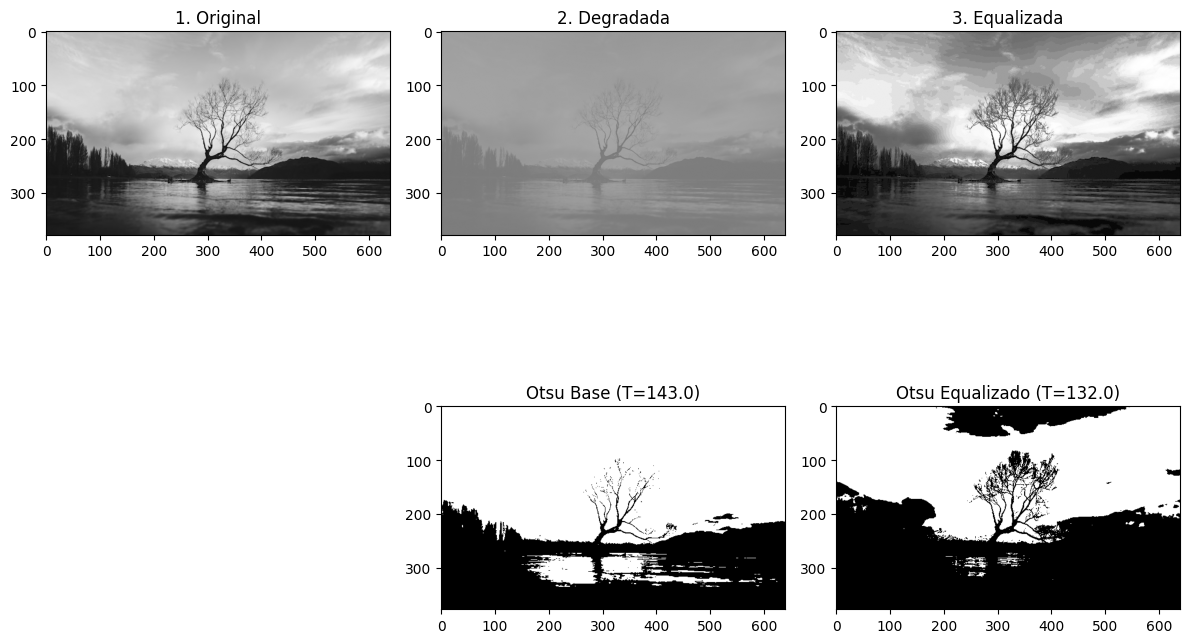

In [6]:
plt.figure(figsize=(12, 8))

# Linha 1: Processamento
plt.subplot(2, 3, 1), plt.title('1. Original'), plt.imshow(img_original, cmap='gray')
plt.subplot(2, 3, 2), plt.title('2. Degradada'), plt.imshow(img_degradada, cmap='gray', vmin=0, vmax=255)
plt.subplot(2, 3, 3), plt.title('3. Equalizada'), plt.imshow(img_equalizada, cmap='gray')

# Linha 2: Resultados da Segmentação
plt.subplot(2, 3, 5), plt.title(f'Otsu Base (T={valor_t_base})'), plt.imshow(img_otsu_base, cmap='gray')
plt.subplot(2, 3, 6), plt.title(f'Otsu Equalizado (T={valor_t_eq})'), plt.imshow(img_otsu_eq, cmap='gray')

plt.tight_layout()
plt.show()

Etapa 5: CLAHE aplicado. Limiar de Otsu (T): 141.0


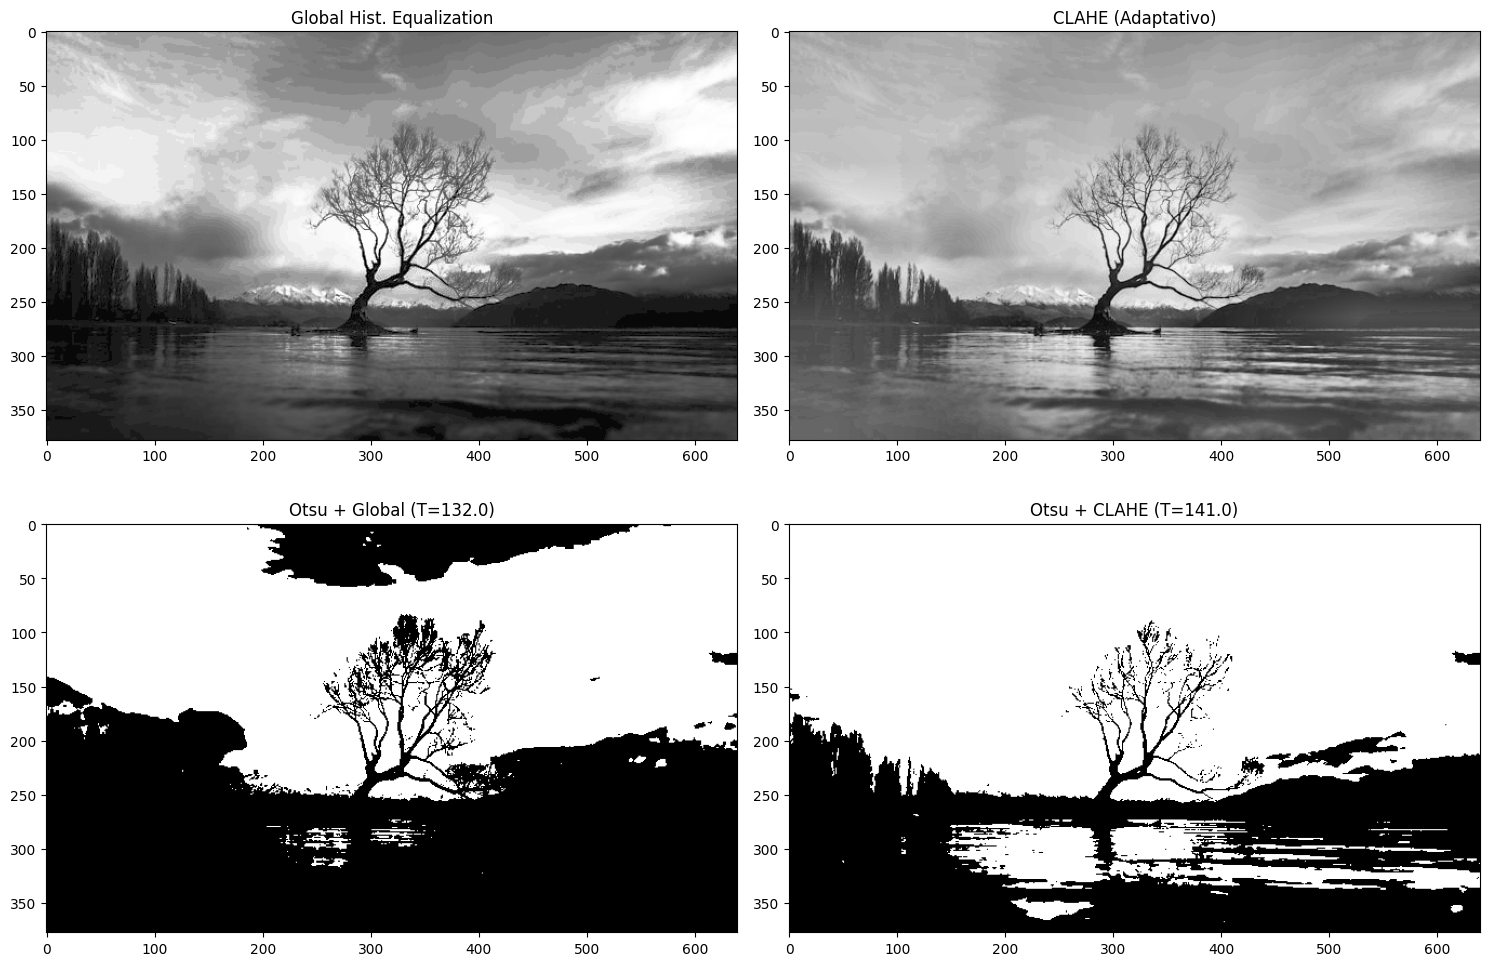

In [7]:
# --- ETAPA 5: Desafio CLAHE ---

# 1. Criar o objeto CLAHE ,onde clipLimit define o limite de contraste, tileGridSize o tamanho dos blocos
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# 2. Aplicar o CLAHE na imagem degradada
img_clahe = clahe.apply(img_degradada)

# 3. Aplicar Otsu na imagem processada pelo CLAHE
valor_t_clahe, img_otsu_clahe = cv2.threshold(
    img_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Etapa 5: CLAHE aplicado. Limiar de Otsu (T): {valor_t_clahe}")

# Visualização do Comparativo Final
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1), plt.title('Global Hist. Equalization'), plt.imshow(img_equalizada, cmap='gray')
plt.subplot(2, 2, 2), plt.title('CLAHE (Adaptativo)'), plt.imshow(img_clahe, cmap='gray')

plt.subplot(2, 2, 3), plt.title(f'Otsu + Global (T={valor_t_eq})'), plt.imshow(img_otsu_eq, cmap='gray')
plt.subplot(2, 2, 4), plt.title(f'Otsu + CLAHE (T={valor_t_clahe})'), plt.imshow(img_otsu_clahe, cmap='gray')

plt.tight_layout()
plt.show()